# XGBoost Post-Mid Model Training
Train XGBoost models on NYISO + Mesonet fusion data with lag feature grid search

In [1]:
import os
import time
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import json
from pathlib import Path

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.1.2


In [2]:
# Configuration
CONFIG = {
    "train_start": 2001,
    "train_end": 2021,
    "val_year": 2022,
    "test_years": [2023, 2024, 2025],

    # Fixed XGBoost model parameters
    "model": {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": "hist",
        "early_stopping_rounds": 20,
        "random_state": 42
    }
}

# Lag feature grid (only parameter being searched)
LAG_GRID = {
    'five': [
        [1, 5, 15],          # short-term only
        [1, 5, 15, 60],      # add 5 hours
        [1, 12, 36, 72]      # 1h, 3h, 6h
    ],
    'quarter': [
        [1, 7, 30],          
        [1, 3, 7, 30],       
        [1, 7, 30, 90]       
    ],
    'hourly': [
        [1, 24, 168],        # 1 hour, day, week
        [1, 24, 72, 168],    # 3 days
        [1, 24, 168, 336]    # 2 weeks 
    ],
    'daily': [
        [1, 7, 30],          # 1 day, week, month
        [1, 3, 7, 30],       # 3 days
        [1, 7, 30, 90]       # 3 months
    ]
}

print("Configuration loaded")
print(f"Model params: {CONFIG['model']}")


Configuration loaded
Model params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}


## Load Master Parquet Data

In [3]:
# Path to master parquet (fusion of NYISO + Mesonet)
MASTER_PATH = Path("../../1_LIB/master/master.parquet")

print(f"Loading fusion dataset from: {MASTER_PATH}")
df = pd.read_parquet(MASTER_PATH)

# Rename and process datetime
df.rename(columns={"datetime": "Time_Stamp"}, inplace=True)
df["Time_Stamp"] = pd.to_datetime(df["Time_Stamp"], utc=True)
df = df.sort_values("Time_Stamp").set_index("Time_Stamp")

# Clean column names (remove special characters)
df.columns = (
    df.columns.str.replace(r"[\[\]\(\)/ ]", "_", regex=True)
              .str.replace(r"__+", "_", regex=True)
              .str.strip("_")
)

print(f"Loaded fusion dataset: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDate range: {df.index.min()} to {df.index.max()}")


Loading fusion dataset from: ..\..\1_LIB\master\master.parquet


Loaded fusion dataset: 1,057,304 rows
Columns: ['latitude_degrees_north', 'longitude_degrees_east', 'elevation_feet', 'temp_2m_degF', 'temp_9m_degF', 'apparent_temperature_degF', 'relative_humidity_percent', 'dewpoint_degF', 'precip_incremental_inch', 'precip_local_inch', 'precip_max_intensity_inch_hour', 'precip_1hr_inch', 'avg_wind_speed_prop_mile_hr', 'max_wind_speed_prop_mile_hr', 'wind_speed_stddev_prop_mile_hr', 'wind_direction_prop_degrees', 'wind_direction_stddev_prop_degrees', 'avg_wind_speed_sonic_mile_hr', 'max_wind_speed_sonic_mile_hr', 'wind_speed_stddev_sonic_mile_hr', 'wind_direction_sonic_degrees', 'wind_direction_stddev_sonic_degrees', 'avg_wind_speed_merge_mile_hr', 'max_wind_speed_merge_mile_hr', 'wind_speed_stddev_merge_mile_hr', 'wind_direction_merge_degrees', 'wind_direction_stddev_merge_degrees', 'solar_insolation_W_m^2', 'station_pressure_inHg', 'frozen_soil_05cm_bit', 'frozen_soil_25cm_bit', 'frozen_soil_50cm_bit', 'soil_temp_05cm_degF', 'soil_temp_25cm_degF', 

In [4]:
# Split weather and load columns
weather_cols = [c for c in df.columns if c not in ["Load", "PTID"]]

# Fill NAs safely (forward fill → 0)
df[weather_cols] = df[weather_cols].ffill().fillna(0)

print(f"\nWeather features ({len(weather_cols)}): {weather_cols[:10]}...")
print(f"\nFirst few rows:")
print(df.head())



Weather features (39): ['latitude_degrees_north', 'longitude_degrees_east', 'elevation_feet', 'temp_2m_degF', 'temp_9m_degF', 'apparent_temperature_degF', 'relative_humidity_percent', 'dewpoint_degF', 'precip_incremental_inch', 'precip_local_inch']...

First few rows:
                           latitude_degrees_north  longitude_degrees_east  \
Time_Stamp                                                                  
2015-08-10 04:00:00+00:00                  43.117               -73.57829   
2015-08-10 04:05:00+00:00                  43.117               -73.57829   
2015-08-10 04:10:00+00:00                  43.117               -73.57829   
2015-08-10 04:15:00+00:00                  43.117               -73.57829   
2015-08-10 04:20:00+00:00                  43.117               -73.57829   

                           elevation_feet  temp_2m_degF  temp_9m_degF  \
Time_Stamp                                                              
2015-08-10 04:00:00+00:00             103   

In [5]:
# Check time resolution
time_diffs = df.index.to_series().diff()
print("\nTime difference between consecutive rows:")
print(time_diffs.value_counts().head(10))



Time difference between consecutive rows:
Time_Stamp
0 days 00:05:00     1057150
0 days 00:10:00          93
0 days 00:15:00          46
0 days 01:05:00          10
1 days 00:05:00           1
24 days 00:05:00          1
7 days 00:05:00           1
0 days 18:00:00           1
Name: count, dtype: int64


## Create Time Aggregations

In [6]:
print("Creating aggregates...")

# 5-minute (original resolution from master parquet)
five = df.copy()

# 15-minute
quarter = df.resample("15min").agg({
    **{c: "mean" for c in weather_cols},
    "Load": "mean"
})

# Hourly
hourly = df.resample("1h").agg({
    **{c: "mean" for c in weather_cols},
    "Load": "mean"
})

# Daily
daily = df.resample("1d").agg({
    **{c: "mean" for c in weather_cols},
    "Load": "mean"
})

AGG_DFS = {
    'five': five,
    'quarter': quarter,
    'hourly': hourly,
    'daily': daily
}

# Print shapes
for name, agg_df in AGG_DFS.items():
    print(f"{name:8} → {len(agg_df):,} rows")


Creating aggregates...


five     → 1,057,304 rows
quarter  → 355,680 rows
hourly   → 88,920 rows
daily    → 3,706 rows


In [7]:
# Display sample of each aggregation
print("\n5-minute sample:")
print(five.head(3))
print("\nQuarter-hour sample:")
print(quarter.head(3))



5-minute sample:
                           latitude_degrees_north  longitude_degrees_east  \
Time_Stamp                                                                  
2015-08-10 04:00:00+00:00                  43.117               -73.57829   
2015-08-10 04:05:00+00:00                  43.117               -73.57829   
2015-08-10 04:10:00+00:00                  43.117               -73.57829   

                           elevation_feet  temp_2m_degF  temp_9m_degF  \
Time_Stamp                                                              
2015-08-10 04:00:00+00:00             103           0.0           0.0   
2015-08-10 04:05:00+00:00             103           0.0           0.0   
2015-08-10 04:10:00+00:00             103           0.0           0.0   

                           apparent_temperature_degF  \
Time_Stamp                                             
2015-08-10 04:00:00+00:00                        0.0   
2015-08-10 04:05:00+00:00                        0.0   
2015-0

## XGBoost Training Function

In [8]:
def run_xgboost(df, lags, agg_name, plot=False):
    """
    Train XGBoost with fixed hyperparameters.
    Only lag features are varied.
    """
    start_time = time.time()

    df = df.copy().reset_index()
    df["year"] = df["Time_Stamp"].dt.year

    # Create lag features
    for lag in lags:
        df[f"lag_{lag}"] = df["Load"].shift(lag)

    df = df.dropna()

    # Identify feature columns
    weather_cols_clean = [
        c for c in df.columns
        if c not in ["Time_Stamp", "Load", "PTID", "year"]
        and not c.startswith("lag_")
    ]
    
    lag_cols = [f"lag_{l}" for l in lags]
    feature_cols = weather_cols_clean + lag_cols

    # Split data
    train = df[
        (df["year"] >= CONFIG["train_start"]) &
        (df["year"] <= CONFIG["train_end"])
    ]
    val = df[df["year"] == CONFIG["val_year"]]
    test = df[df["year"].isin(CONFIG["test_years"])]

    X_train = train[feature_cols]
    y_train = train["Load"]
    X_val = val[feature_cols]
    y_val = val["Load"]
    X_test = test[feature_cols]
    y_test = test["Load"]

    print(f"\n[{agg_name}] Train={len(train):,}, Val={len(val):,}, Test={len(test):,}")
    print(f"  Features: {len(feature_cols)} ({len(weather_cols_clean)} weather + {len(lag_cols)} lags)")
    print(f"  Lags={lags}")

    # Train model
    model = xgb.XGBRegressor(**CONFIG["model"])
    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        verbose=False
    )

    # Predictions
    y_val_pred = model.predict(X_val)
    y_pred = model.predict(X_test)

    # Validation metrics
    rmse_val = root_mean_squared_error(y_val, y_val_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    r2_val = r2_score(y_val, y_val_pred)
    mask_val = y_val != 0
    mape_val = (abs((y_val[mask_val] - y_val_pred[mask_val]) / y_val[mask_val])).mean() * 100

    # Test metrics
    rmse_test = root_mean_squared_error(y_test, y_pred)
    mae_test = mean_absolute_error(y_test, y_pred)
    r2_test = r2_score(y_test, y_pred)
    mask_test = y_test != 0
    mape_test = (abs((y_test[mask_test] - y_pred[mask_test]) / y_test[mask_test])).mean() * 100

    elapsed = time.time() - start_time

    print(f"  VAL  → MAPE={mape_val:.3f}% | MAE={mae_val:.2f} | RMSE={rmse_val:.2f} | R²={r2_val:.4f}")
    print(f"  TEST → MAPE={mape_test:.3f}% | MAE={mae_test:.2f} | RMSE={rmse_test:.2f} | R²={r2_test:.4f}")
    print(f"  Time → {elapsed:.2f}s")

    if plot:
        plt.figure(figsize=(14, 6))
        plt.plot(test["Time_Stamp"].values, y_test.values, label="Actual", alpha=0.6)
        plt.plot(test["Time_Stamp"].values, y_pred, label="Predicted", alpha=0.8)
        plt.title(f"{agg_name} — Actual vs Predicted Load (lags={lags})")
        plt.xlabel("Time")
        plt.ylabel("Load (MW)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "MAPE_val": mape_val,
        "MAE_val": mae_val,
        "RMSE_val": rmse_val,
        "R2_val": r2_val,
        "MAPE": mape_test,
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test,
        "Time_s": elapsed,
        "lags": lags,
        "params": CONFIG["model"].copy()
    }

print("XGBoost training function defined")


XGBoost training function defined


## Grid Search for Optimal Lags

In [9]:
def gridsearch_for_agg(df, agg_name):
    """
    Grid search over lag configurations.
    Select best based on validation MAPE.
    """
    lag_candidates = LAG_GRID[agg_name]
    print(f"\n{'='*60}")
    print(f"GRID SEARCH: {agg_name.upper()}")
    print(f"{'='*60}")
    print(f"Fixed hyperparameters: {CONFIG['model']}")
    print(f"Lag candidates: {lag_candidates}")

    best = None
    best_lags = None
    all_results = []

    for lags in lag_candidates:
        print(f"\n--- Trying lags={lags} ---")
        metrics = run_xgboost(df, lags, agg_name, plot=False)
        all_results.append(metrics)

        if (best is None) or (metrics["MAPE_val"] < best["MAPE_val"]):
            best = metrics
            best_lags = lags

    print(f"\n{'='*60}")
    print(f"BEST CONFIG for {agg_name}:")
    print(f"{'='*60}")
    print(f"  Lags:      {best_lags}")
    print(f"  VAL MAPE:  {best['MAPE_val']:.3f}%")
    print(f"  TEST MAPE: {best['MAPE']:.3f}%")
    print(f"  TEST MAE:  {best['MAE']:.2f}")
    print(f"  TEST RMSE: {best['RMSE']:.2f}")
    print(f"  TEST R²:   {best['R2']:.4f}")

    # Plot best configuration
    print("\nGenerating plot for best configuration...")
    _ = run_xgboost(df, best_lags, agg_name, plot=True)

    return best, all_results

print("Grid search function defined")


Grid search function defined


## Run Grid Search for All Aggregations



######################################################################
# Processing: FIVE aggregation
######################################################################

GRID SEARCH: FIVE
Fixed hyperparameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}
Lag candidates: [[1, 5, 15], [1, 5, 15, 60], [1, 12, 36, 72]]

--- Trying lags=[1, 5, 15] ---



[five] Train=663,195, Val=105,092, Test=288,906
  Features: 42 (39 weather + 3 lags)
  Lags=[1, 5, 15]


  VAL  → MAPE=0.253% | MAE=4.02 | RMSE=5.37 | R²=0.9997
  TEST → MAPE=0.267% | MAE=4.16 | RMSE=5.87 | R²=0.9996
  Time → 5.64s

--- Trying lags=[1, 5, 15, 60] ---



[five] Train=663,126, Val=105,092, Test=288,903
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 5, 15, 60]


  VAL  → MAPE=0.267% | MAE=4.23 | RMSE=5.60 | R²=0.9996
  TEST → MAPE=0.286% | MAE=4.44 | RMSE=6.16 | R²=0.9995
  Time → 5.95s

--- Trying lags=[1, 12, 36, 72] ---



[five] Train=663,111, Val=105,092, Test=288,903
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 12, 36, 72]


  VAL  → MAPE=0.306% | MAE=4.85 | RMSE=6.41 | R²=0.9995
  TEST → MAPE=0.332% | MAE=5.15 | RMSE=7.00 | R²=0.9994
  Time → 6.78s

BEST CONFIG for five:
  Lags:      [1, 5, 15]
  VAL MAPE:  0.253%
  TEST MAPE: 0.267%
  TEST MAE:  4.16
  TEST RMSE: 5.87
  TEST R²:   0.9996

Generating plot for best configuration...



[five] Train=663,195, Val=105,092, Test=288,906
  Features: 42 (39 weather + 3 lags)
  Lags=[1, 5, 15]


  VAL  → MAPE=0.253% | MAE=4.02 | RMSE=5.37 | R²=0.9997
  TEST → MAPE=0.267% | MAE=4.16 | RMSE=5.87 | R²=0.9996
  Time → 6.29s


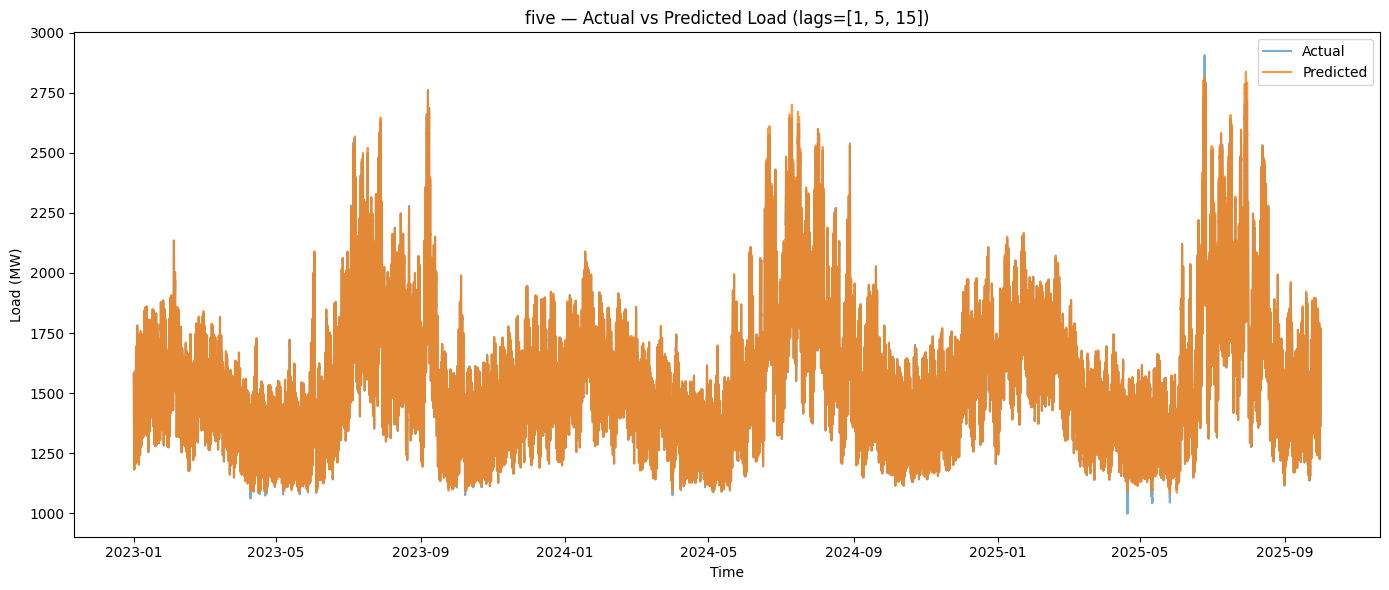



######################################################################
# Processing: QUARTER aggregation
######################################################################

GRID SEARCH: QUARTER
Fixed hyperparameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}
Lag candidates: [[1, 7, 30], [1, 3, 7, 30], [1, 7, 30, 90]]

--- Trying lags=[1, 7, 30] ---

[quarter] Train=220,953, Val=35,027, Test=96,273
  Features: 42 (39 weather + 3 lags)
  Lags=[1, 7, 30]


  VAL  → MAPE=0.353% | MAE=5.64 | RMSE=7.58 | R²=0.9993
  TEST → MAPE=0.405% | MAE=6.34 | RMSE=8.67 | R²=0.9990
  Time → 2.51s

--- Trying lags=[1, 3, 7, 30] ---



[quarter] Train=220,938, Val=35,025, Test=96,269
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 3, 7, 30]


  VAL  → MAPE=0.326% | MAE=5.23 | RMSE=7.05 | R²=0.9994
  TEST → MAPE=0.369% | MAE=5.78 | RMSE=7.99 | R²=0.9992
  Time → 4.33s

--- Trying lags=[1, 7, 30, 90] ---

[quarter] Train=220,684, Val=35,023, Test=96,205
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 7, 30, 90]


  VAL  → MAPE=0.367% | MAE=5.85 | RMSE=7.84 | R²=0.9993
  TEST → MAPE=0.414% | MAE=6.42 | RMSE=8.76 | R²=0.9990
  Time → 3.54s

BEST CONFIG for quarter:
  Lags:      [1, 3, 7, 30]
  VAL MAPE:  0.326%
  TEST MAPE: 0.369%
  TEST MAE:  5.78
  TEST RMSE: 7.99
  TEST R²:   0.9992

Generating plot for best configuration...

[quarter] Train=220,938, Val=35,025, Test=96,269
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 3, 7, 30]


  VAL  → MAPE=0.326% | MAE=5.23 | RMSE=7.05 | R²=0.9994
  TEST → MAPE=0.369% | MAE=5.78 | RMSE=7.99 | R²=0.9992
  Time → 3.33s


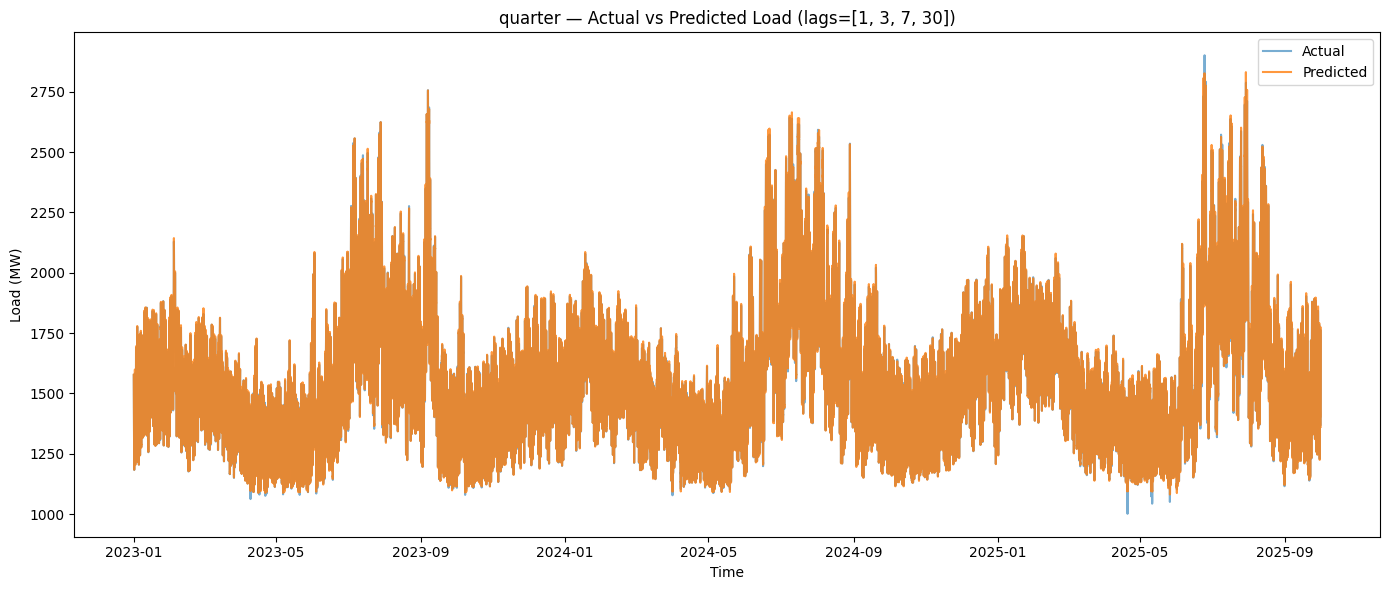



######################################################################
# Processing: HOURLY aggregation
######################################################################

GRID SEARCH: HOURLY
Fixed hyperparameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}
Lag candidates: [[1, 24, 168], [1, 24, 72, 168], [1, 24, 168, 336]]

--- Trying lags=[1, 24, 168] ---

[hourly] Train=54,712, Val=8,756, Test=24,040
  Features: 42 (39 weather + 3 lags)
  Lags=[1, 24, 168]


  VAL  → MAPE=1.484% | MAE=23.00 | RMSE=30.01 | R²=0.9891
  TEST → MAPE=1.661% | MAE=25.34 | RMSE=33.30 | R²=0.9859
  Time → 1.55s

--- Trying lags=[1, 24, 72, 168] ---

[hourly] Train=54,681, Val=8,755, Test=24,021
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 24, 72, 168]


  VAL  → MAPE=1.503% | MAE=23.33 | RMSE=30.50 | R²=0.9888
  TEST → MAPE=1.670% | MAE=25.45 | RMSE=33.50 | R²=0.9857
  Time → 1.39s

--- Trying lags=[1, 24, 168, 336] ---

[hourly] Train=54,177, Val=8,755, Test=24,021
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 24, 168, 336]


  VAL  → MAPE=1.482% | MAE=23.05 | RMSE=29.98 | R²=0.9892
  TEST → MAPE=1.643% | MAE=25.10 | RMSE=32.99 | R²=0.9861
  Time → 1.39s

BEST CONFIG for hourly:
  Lags:      [1, 24, 168, 336]
  VAL MAPE:  1.482%
  TEST MAPE: 1.643%
  TEST MAE:  25.10
  TEST RMSE: 32.99
  TEST R²:   0.9861

Generating plot for best configuration...

[hourly] Train=54,177, Val=8,755, Test=24,021
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 24, 168, 336]


  VAL  → MAPE=1.482% | MAE=23.05 | RMSE=29.98 | R²=0.9892
  TEST → MAPE=1.643% | MAE=25.10 | RMSE=32.99 | R²=0.9861
  Time → 1.36s


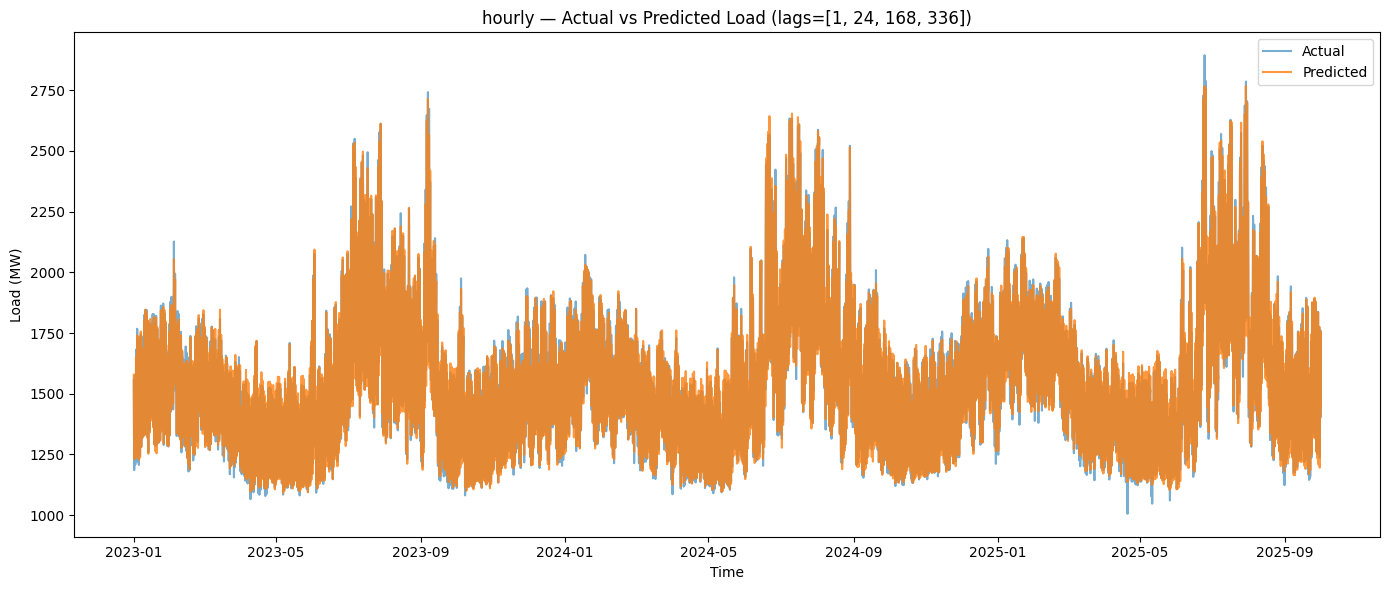



######################################################################
# Processing: DAILY aggregation
######################################################################

GRID SEARCH: DAILY
Fixed hyperparameters: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist', 'early_stopping_rounds': 20, 'random_state': 42}
Lag candidates: [[1, 7, 30], [1, 3, 7, 30], [1, 7, 30, 90]]

--- Trying lags=[1, 7, 30] ---

[daily] Train=2,234, Val=365, Test=1,005
  Features: 42 (39 weather + 3 lags)
  Lags=[1, 7, 30]


  VAL  → MAPE=3.095% | MAE=49.41 | RMSE=67.29 | R²=0.9114
  TEST → MAPE=3.217% | MAE=49.94 | RMSE=67.16 | R²=0.9094
  Time → 0.32s

--- Trying lags=[1, 3, 7, 30] ---

[daily] Train=2,234, Val=365, Test=1,005
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 3, 7, 30]


  VAL  → MAPE=3.077% | MAE=49.11 | RMSE=67.07 | R²=0.9120
  TEST → MAPE=3.270% | MAE=50.82 | RMSE=68.44 | R²=0.9060
  Time → 0.39s

--- Trying lags=[1, 7, 30, 90] ---

[daily] Train=2,145, Val=365, Test=1,005
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 7, 30, 90]


  VAL  → MAPE=2.935% | MAE=46.43 | RMSE=63.88 | R²=0.9202
  TEST → MAPE=3.111% | MAE=48.43 | RMSE=65.50 | R²=0.9139
  Time → 0.46s

BEST CONFIG for daily:
  Lags:      [1, 7, 30, 90]
  VAL MAPE:  2.935%
  TEST MAPE: 3.111%
  TEST MAE:  48.43
  TEST RMSE: 65.50
  TEST R²:   0.9139

Generating plot for best configuration...

[daily] Train=2,145, Val=365, Test=1,005
  Features: 43 (39 weather + 4 lags)
  Lags=[1, 7, 30, 90]


  VAL  → MAPE=2.935% | MAE=46.43 | RMSE=63.88 | R²=0.9202
  TEST → MAPE=3.111% | MAE=48.43 | RMSE=65.50 | R²=0.9139
  Time → 0.44s


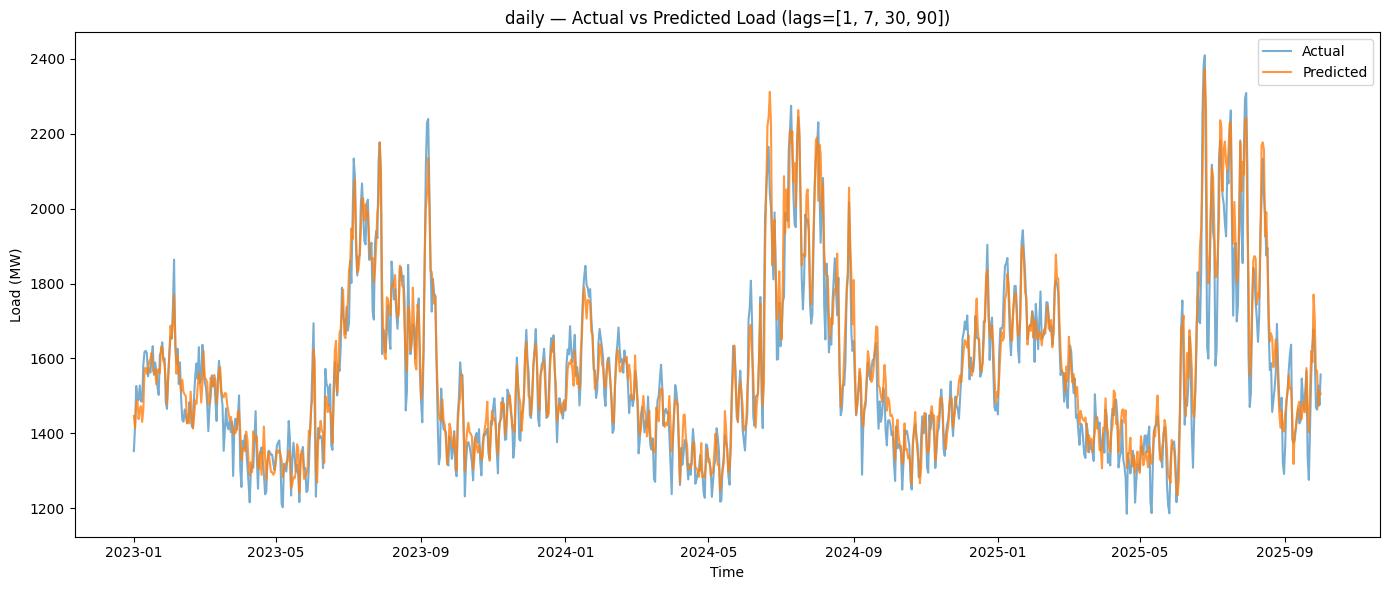



Total runtime: 47.33 seconds (0.79 minutes)


In [10]:
total_start = time.time()

results = {}
all_results_by_agg = {}

for agg_name, df_agg in AGG_DFS.items():
    print(f"\n\n{'#'*70}")
    print(f"# Processing: {agg_name.upper()} aggregation")
    print(f"{'#'*70}")
    
    best_result, all_configs = gridsearch_for_agg(df_agg, agg_name)
    results[agg_name] = best_result
    all_results_by_agg[agg_name] = all_configs

total_time = time.time() - total_start
print(f"\n\nTotal runtime: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")


## Results Summary

In [11]:
# Build summary table (TEST metrics only)
summary = {}
for agg_name, res in results.items():
    summary[agg_name] = {
        "MAPE": res["MAPE"],
        "MAE": res["MAE"],
        "RMSE": res["RMSE"],
        "R2": res["R2"],
        "Time_s": res["Time_s"],
    }

summary_df = pd.DataFrame(summary).T[["MAPE", "MAE", "RMSE", "R2", "Time_s"]]

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY (TEST SET)")
print("="*70)
print(summary_df.round(4))



FINAL RESULTS SUMMARY (TEST SET)
           MAPE      MAE     RMSE      R2  Time_s
five     0.2671   4.1620   5.8652  0.9996  5.6388
quarter  0.3693   5.7808   7.9910  0.9992  4.3283
hourly   1.6426  25.1026  32.9883  0.9861  1.3917
daily    3.1108  48.4298  65.4995  0.9139  0.4564


In [12]:
# Display optimal lags
print("\n" + "="*70)
print("OPTIMAL LAG CONFIGURATIONS")
print("="*70)
for agg_name, res in results.items():
    print(f"{agg_name:8} → {res['lags']}")



OPTIMAL LAG CONFIGURATIONS
five     → [1, 5, 15]
quarter  → [1, 3, 7, 30]
hourly   → [1, 24, 168, 336]
daily    → [1, 7, 30, 90]


In [13]:
# Save results to JSON
output_file = "results_new.json"
with open(output_file, "w") as f:
    json.dump(summary, f, indent=4)

print(f"\n✓ Saved results to: {output_file}")

# Also save full results with all configurations
full_results_file = "results_new_full.json"
full_results = {
    "summary": summary,
    "best_configs": {k: v for k, v in results.items()},
    "all_configs": all_results_by_agg
}
with open(full_results_file, "w") as f:
    json.dump(full_results, f, indent=4)

print(f"✓ Saved full results to: {full_results_file}")



✓ Saved results to: results_new.json
✓ Saved full results to: results_new_full.json


## Comparison with Baseline (if available)

In [14]:
# Try to load old results for comparison
try:
    with open("results_old.json", "r") as f:
        old_results = json.load(f)
    
    print("\n" + "="*70)
    print("IMPROVEMENT OVER BASELINE (NYISO-only)")
    print("="*70)
    
    comparison = pd.DataFrame({
        "Old_MAPE": [old_results.get(k, {}).get("MAPE", np.nan) for k in summary.keys()],
        "New_MAPE": [summary[k]["MAPE"] for k in summary.keys()],
        "Old_R2": [old_results.get(k, {}).get("R2", np.nan) for k in summary.keys()],
        "New_R2": [summary[k]["R2"] for k in summary.keys()],
    }, index=summary.keys())
    
    comparison["MAPE_Δ%"] = ((comparison["Old_MAPE"] - comparison["New_MAPE"]) / comparison["Old_MAPE"] * 100)
    comparison["R2_Δ%"] = ((comparison["New_R2"] - comparison["Old_R2"]) / comparison["Old_R2"] * 100)
    
    print(comparison.round(4))
    
except FileNotFoundError:
    print("\nresults_old.json not found - skipping comparison")



IMPROVEMENT OVER BASELINE (NYISO-only)
         Old_MAPE  New_MAPE  Old_R2  New_R2  MAPE_Δ%    R2_Δ%
five       0.3330    0.2671  0.9994  0.9996  19.7888   0.0185
quarter    0.4523    0.3693  0.9987  0.9992  18.3613   0.0532
hourly     2.5470    1.6426  0.9680  0.9861  35.5074   1.8777
daily      4.3750    3.1108  0.8226  0.9139  28.8955  11.0920
